<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/Data620_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias
<br>Assignment week 10- SMS Spam detection Using Machine Learning

<br>It can be useful to be able to classify new "test" documents using already classified "training" documents.  A common example is using a corpus of labeled spam and ham (non-spam) e-mails to predict whether or not a new document is spam.  Here is one example of such data:  UCI Machine Learning Repository: Spambase Data Set

For this project, you can either use the above dataset to predict the class of new documents (either withheld from the training dataset or from another source such as your own spam folder).

For more adventurous students, you are welcome (encouraged!) to come up a different set of documents (including scraped web pages!?) that have already been classified (e.g. tagged), then analyze these documents to predict how new documents should be classified.

<br> The dataset I will be using is a SMS spam collection public dataset from https://archive.ics.uci.edu/dataset/228/sms+spam+collection. The dataset has label messages that have been collect from cellphone text spam research. The datase is a "collection of 425 SMS spam messages was manually extracted from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received."

In [73]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#for machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
#for models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
#for evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



Initially the dataset resulted in a BadZipFile error because the URL pointed to a webpage rather than the actual ZIP archive. After correcting the URL to the direct download link, a second issue arose because the ZIP file contained multiple files, which pandas.read_csv could not handle directly. This was resolved by using Python’s zipfile function and requests libraries to manually extract the specific data file (SMSSpamCollection) before loading it into a dataframe.

In [74]:
#load dataset directly from website
import requests
import zipfile
import io

url="https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# download the zip file
response = requests.get(url)
response.raise_for_status() # recommended by Gemini raise an HTTPError for bad responses (4xx or 5xx)

# open the zip file from memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Read the desired file (SMSSpamCollection) from the zip
    with z.open('SMSSpamCollection') as f:
        df = pd.read_csv(f, sep='\t', header=None, names=["label", "message"])

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Data exploration

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


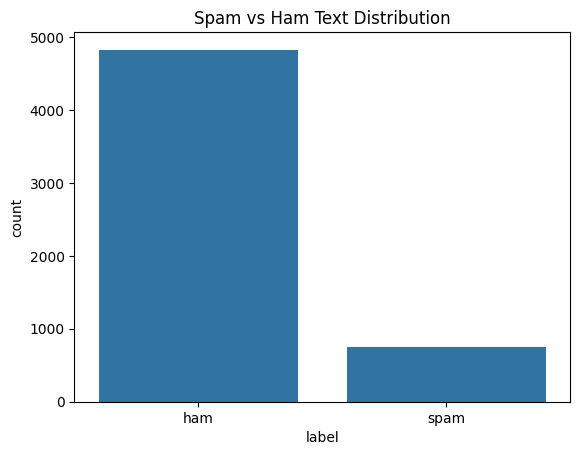

In [75]:
print(df.shape)
print(df['label'].value_counts())

sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Text Distribution")
plt.show()

Encoded labels into numbers for analysis

In [76]:
df["label_num"]=df["label"].map({"ham":0, "spam":1})

Train/test split

In [77]:
X=df["message"]
y=df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Built models Naive Bayes, Logistic Regression, and support vector machine.

In [78]:
#Naive Bayes
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clf', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
nb_pred = nb_pipeline.predict(X_test)

In [79]:
#Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clf', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

In [80]:
#Support vector machine
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clf', LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

Evaluation- cretaed function to obtain results to compare.

In [81]:
def evaluate_model(name, y_test, y_pred):
    print(f"---{name}---")
    print("Accuracy:", accuracy_score(y_test,y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("/n")

In [82]:
#run evaluation function
evaluate_model("Naive Bayes",y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Support Vector Machine", y_test, svm_pred)

---Naive Bayes---
Accuracy: 0.97847533632287
[[966   0]
 [ 24 125]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

/n
---Logistic Regression---
Accuracy: 0.9695067264573991
[[966   0]
 [ 34 115]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

/n
---Support Vector Machine---
Accuracy: 0.9901345291479821
[[965   1]
 [ 10 139]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
    

Test custom messages

In [83]:
messages=["You've won a Free ticket!", "Hey, are you still meeting tonight",  "Urgent! Call this number now to claim your prize", "Can you send me the report?"]

print("Naive Bayes Predictions:", nb_pipeline.predict(messages))
print("Logistic Regression Predictions:",lr_pipeline.predict(messages))
print("SVM Predictions:",svm_pipeline.predict(messages))

Naive Bayes Predictions: [0 0 1 0]
Logistic Regression Predictions: [0 0 1 0]
SVM Predictions: [0 0 1 0]


Tried model improvement by adding bigram to Naive Bayes model and class weight as balanced for logistic regression to help the model pay attention to minority class (the spam class in this case), and for the support vector machine model the parameter C=10.0 was used to control the trade-off between maximizing the margin and minimizing classification error, providing a balanced generalization performance.

In [84]:
#Naive Bayes 2
nb2_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english",ngram_range=(1,2))),
    ('clf', MultinomialNB())
])

nb2_pipeline.fit(X_train, y_train)
nb2_pred = nb2_pipeline.predict(X_test)

In [85]:
#Logistic Regression 2
lr2_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clf', LogisticRegression(class_weight="balanced"))
])

lr2_pipeline.fit(X_train, y_train)
lr2_pred = lr2_pipeline.predict(X_test)

In [86]:
#Support vector machine 2
svm2_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('clf', LinearSVC(C=10.0))
])

svm2_pipeline.fit(X_train, y_train)
svm2_pred = svm2_pipeline.predict(X_test)

In [87]:
#run evaluation function for second models
evaluate_model("Naive Bayes 2",y_test, nb2_pred)
evaluate_model("Logistic Regression 2", y_test, lr2_pred)
evaluate_model("Support Vector Machine 2", y_test, svm2_pred)

---Naive Bayes 2---
Accuracy: 0.9650224215246637
[[966   0]
 [ 39 110]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115

/n
---Logistic Regression 2---
Accuracy: 0.9856502242152466
[[957   9]
 [  7 142]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115

/n
---Support Vector Machine 2---
Accuracy: 0.9928251121076234
[[965   1]
 [  7 142]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       

In [88]:
print("Naive Bayes 2 Predictions:", nb2_pipeline.predict(messages))
print("Logistic Regression 2 Predictions:",lr2_pipeline.predict(messages))
print("SVM 2 Predictions:",svm2_pipeline.predict(messages))

Naive Bayes 2 Predictions: [0 0 1 0]
Logistic Regression 2 Predictions: [1 0 1 0]
SVM 2 Predictions: [0 0 1 0]


The Initial results showed strong performance across all models, with the Support Vector Machine achieving the highest accuracy (approximately 99%), followed closely by Naive Bayes and Logistic Regression. Evaluation metrics such as precision, recall, and F1 score confirmed that the models were highly effective at distinguishing between spam and legitimate messages, although recall for the spam class was slightly lower in some cases due to class imbalance.

Bigram features were introduced in the Naive Bayes model to capture word pairs and improve contextual understanding. Additionally, class weighting was applied to logistic Regression to address dataset imbalance by placing greater emphasis on the minority class (spam), and the SVM model's regularization parameter was adjusted to improve generalization. These modifications resulted in slight improvements in recall for spam detection, particularly in the enhanced Logistic Regression and SVM models. Still some misclassifications remained, especially for messages containing ambiguous wording or uncommon spam phrases. This highlights a key limitation of TF-IDF based bag of words models, which rely on surface level word frequency patterns rather than deeper semantic meaning. But the improvement on the logistic model actually made the correct predictions to the messages I created.


<br> Overall, it seems SVM had the best performance in this case. Future improvements could involve using more advanced techniques such as word embeddings or transformer based models, which are better able to capture contextual and semantic meaning in text (like the word "free").